In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, LearningCurveDisplay , StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier


from xgboost import XGBClassifier

In [3]:
df = pd.read_csv('medical_insurance.csv')
print("Shape data:", df.shape)

Shape data: (100000, 54)


In [4]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [6]:
missing = df.isnull().sum()
print("Kolom dengan data kosong:")
print(missing[missing > 0])

Kolom dengan data kosong:
alcohol_freq    30083
dtype: int64


In [7]:
df['alcohol_freq'] = df['alcohol_freq'].fillna('Unknown')
print("Missing setelah diisi:", df.isnull().sum().sum())

Missing setelah diisi: 0


In [8]:
le = LabelEncoder()
cat_cols = ['sex', 'smoker', 'alcohol_freq', 'employment_status']

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [9]:
feature_cols = [
    'age', 'sex', 'bmi', 'smoker', 'alcohol_freq',
    'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
    'visits_last_year', 'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs', 'medication_count',
    'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
    'proc_consult_count', 'proc_lab_count',
]

X = df[feature_cols]
y = df['is_high_risk']

print("Jumlah fitur yang dipakai:", len(feature_cols))
print("Distribusi target:")
print(y.value_counts().rename({0: 'Not High Risk', 1: 'High Risk'}))

Jumlah fitur yang dipakai: 18
Distribusi target:
is_high_risk
Not High Risk    63219
High Risk        36781
Name: count, dtype: int64


In [10]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Data training:", X_train.shape[0])
print("Data testing :", X_test.shape[0])

Data training: 80000
Data testing : 20000


### XGBoost

In [12]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
y_pred = model.predict(X_test)

print("=== HASIL TESTING ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

=== HASIL TESTING ===
Accuracy : 0.90375
Precision: 0.9087761553514978
F1-Score : 0.8624901778698478


In [14]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[12038   606]
 [ 1319  6037]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.93     12644
           1       0.91      0.82      0.86      7356

    accuracy                           0.90     20000
   macro avg       0.91      0.89      0.89     20000
weighted avg       0.90      0.90      0.90     20000



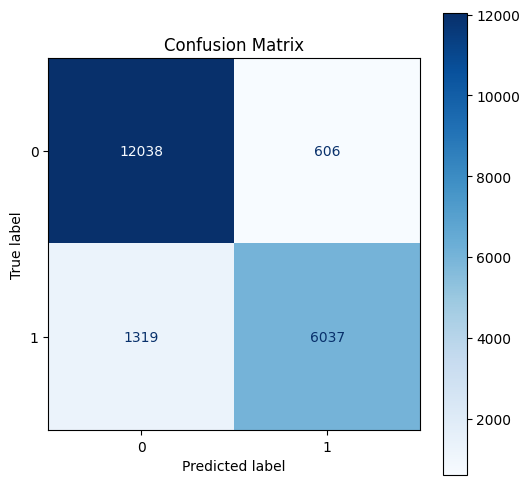

In [15]:

display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    normalize=None
)

display.figure_.set_size_inches(6, 6)
plt.title("Confusion Matrix")
plt.show()

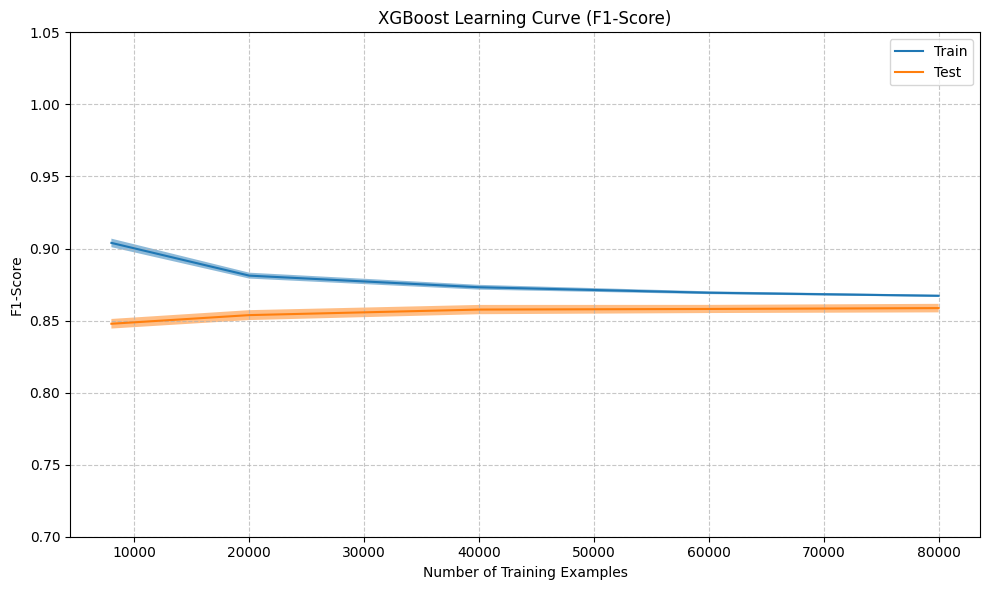

In [16]:
cv_strategy = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
display = LearningCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    cv=cv_strategy,
    scoring='f1',
    score_type="both",
    n_jobs=-1,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0]
)

display.figure_.set_size_inches(10, 6)
plt.title("XGBoost Learning Curve (F1-Score)")
plt.xlabel("Number of Training Examples")
plt.ylabel("F1-Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.7, 1.05)

plt.tight_layout()
plt.show()

### Random Forest

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_train_acc = rf_model.score(X_train, y_train)
rf_val_acc = rf_model.score(X_test, y_test)

print("Random Forest Training Accuracy:", rf_train_acc)
print("Random Forest Validation Accuracy:", rf_val_acc)
print("\nClassifiation Report (RF):")
print(classification_report(y_test, rf_model.predict(X_test)))

Random Forest Training Accuracy: 1.0
Random Forest Validation Accuracy: 0.9001

Classifiation Report (RF):
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     12644
           1       0.90      0.82      0.86      7356

    accuracy                           0.90     20000
   macro avg       0.90      0.88      0.89     20000
weighted avg       0.90      0.90      0.90     20000



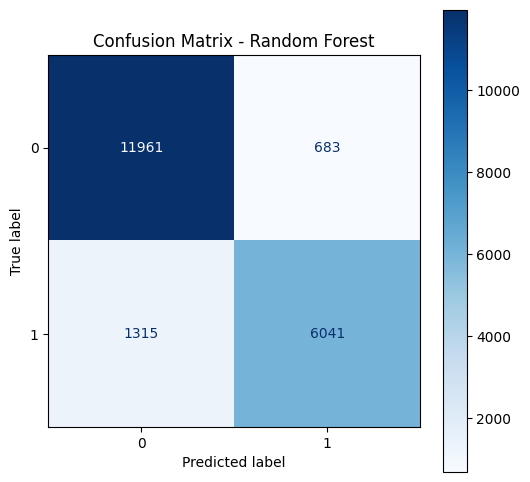

In [18]:
rf_preds = rf_model.predict(X_test)

display_rf = ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, cmap="Blues", normalize=None)
display_rf.figure_.set_size_inches(6, 6)
plt.title("Confusion Matrix - Random Forest")
plt.show()

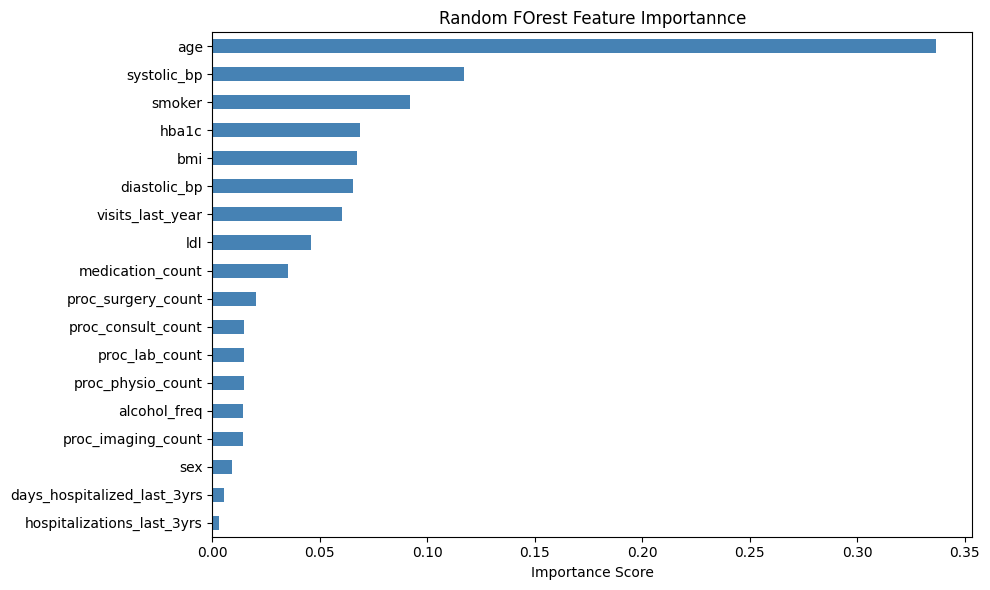

In [19]:
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
feat_imp.plot(kind='barh', color='steelblue')
plt.title("Random FOrest Feature Importannce")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

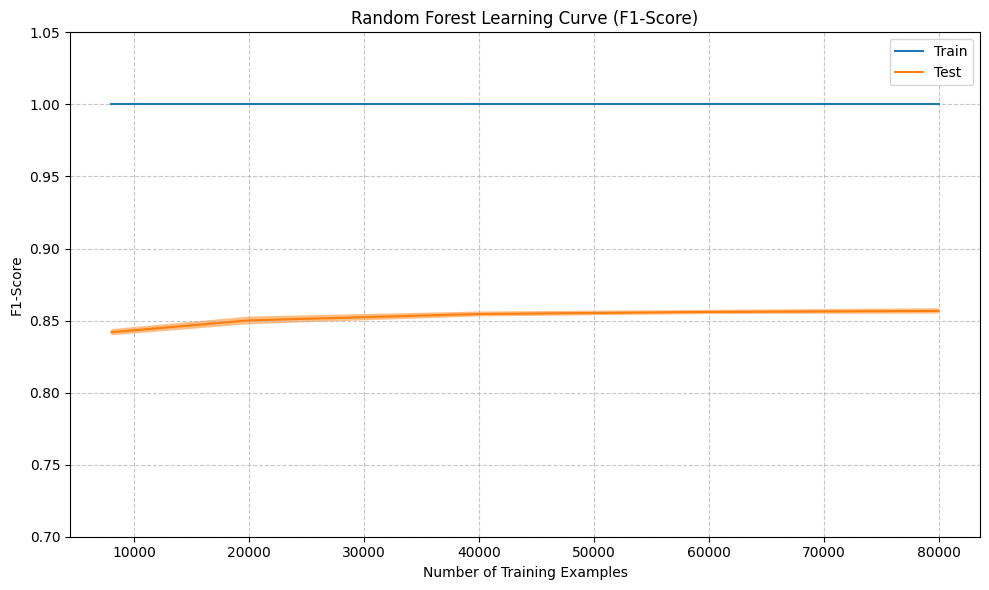

In [20]:
cv_strategy_rf = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
display_lc_rf = LearningCurveDisplay.from_estimator(
    estimator=rf_model,
    X=X_scaled,
    y=y,
    cv=cv_strategy_rf,
    scoring='f1',
    score_type="both",
    n_jobs=-1,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0]
)
display_lc_rf.figure_.set_size_inches(10, 6)
plt.title("Random Forest Learning Curve (F1-Score)")
plt.xlabel("Number of Training Examples")
plt.ylabel("F1-Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

###Decision Tree

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [22]:
dt_model = DecisionTreeClassifier(
    max_depth=10, random_state=42
)
dt_model.fit(X_train, y_train)

dt_train_acc = dt_model.score(X_train, y_train)
dt_val_acc = dt_model.score(X_test, y_test)

print("Decision Tree Training Accuracy:", dt_train_acc)
print("Decision Tree Validation Accuracy:", dt_val_acc)
print("\nClassification Report (DT):")
print(classification_report(y_test, dt_model.predict(X_test)))

Decision Tree Training Accuracy: 0.8960125
Decision Tree Validation Accuracy: 0.8901

Classification Report (DT):
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     12644
           1       0.89      0.80      0.84      7356

    accuracy                           0.89     20000
   macro avg       0.89      0.87      0.88     20000
weighted avg       0.89      0.89      0.89     20000



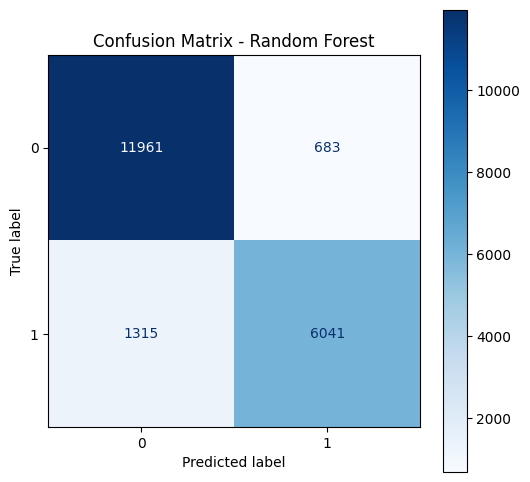

In [23]:
rf_preds = rf_model.predict(X_test)

display_rf = ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, cmap="Blues", normalize=None)
display_rf.figure_.set_size_inches(6, 6)
plt.title("Confusion Matrix - Random Forest")
plt.show()

#**Logistic**

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_train_acc = lr_model.score(X_train, y_train)
lr_val_acc = lr_model.score(X_test, y_test)

print("Logistic Regression")
print("Train Accuracy logistic:", lr_train_acc)
print("Val Accuracy Logistic:", lr_val_acc)
print("\nClassification Report (LR):")
print(classification_report(y_test, lr_model.predict(X_test)))

Logistic Regression
Train Accuracy logistic: 0.8573875
Val Accuracy Logistic: 0.861

Classification Report (LR):
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     12644
           1       0.83      0.79      0.81      7356

    accuracy                           0.86     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



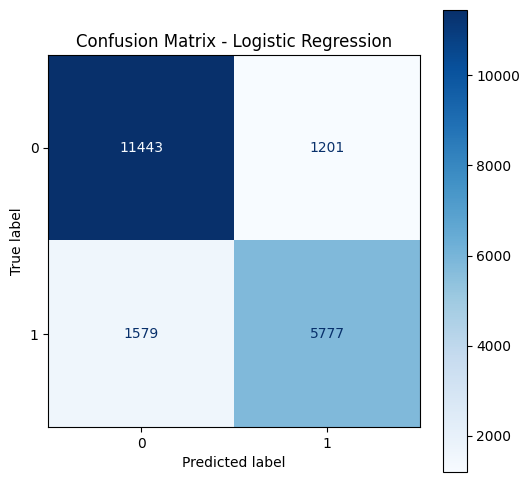

In [26]:
lr_preds = lr_model.predict(X_test)

display_lr = ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, cmap="Blues", normalize=None)

display_lr.figure_.set_size_inches(6, 6)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

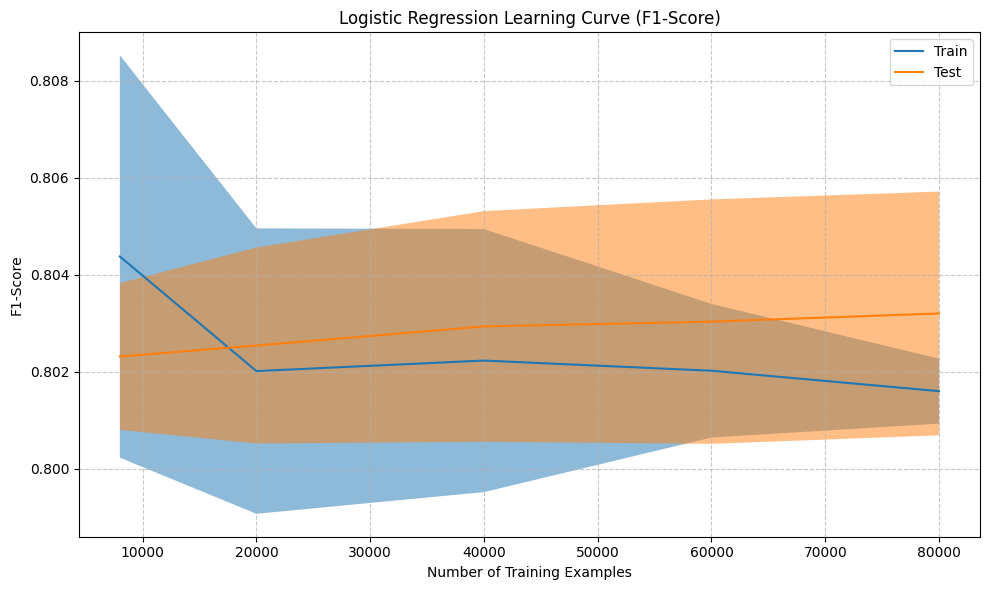

In [27]:
cv_strategy_lr = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
display_lc_lr = LearningCurveDisplay.from_estimator(
    estimator=lr_model, X=X_scaled, y=y, cv=cv_strategy_lr, scoring='f1', score_type="both", n_jobs=-1, train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0])
display_lc_lr.figure_.set_size_inches(10, 6)
plt.title("Logistic Regression Learning Curve (F1-Score)")
plt.xlabel("Number of Training Examples")
plt.ylabel("F1-Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

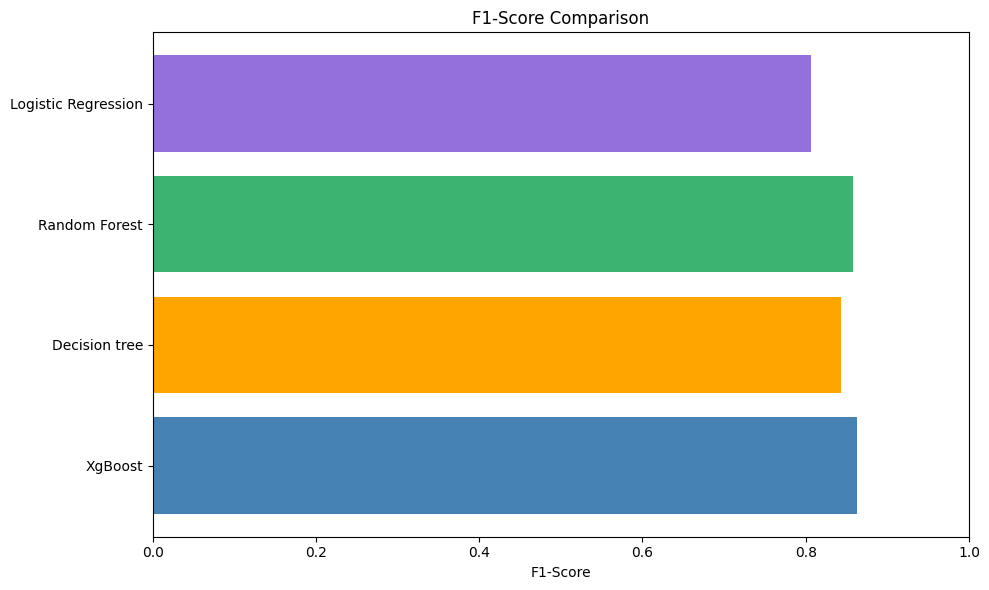

In [28]:
results = {
    'XgBoost': f1_score(y_test, model.predict(X_test)),
    'Decision tree':f1_score(y_test, dt_model.predict(X_test)),
    'Random Forest': f1_score(y_test, rf_model.predict(X_test)),
    'Logistic Regression': f1_score(y_test, lr_model.predict(X_test))
}

plt.figure(figsize=(10, 6))
plt.barh(list(results.keys()), list(results.values()), color=['steelblue','orange','mediumseagreen','mediumpurple'])
plt.xlim(0, 1)
plt.xlabel('F1-Score')
plt.title('F1-Score Comparison')
plt.tight_layout()
plt.show()

In [29]:
joblib.dump(model, "XGB_pkl")
joblib.dump(rf_model, "RF_pkl")
joblib.dump(dt_model, "DT_pkl")
joblib.dump(lr_model, "LR_pkl")

['LR_pkl']

Exception ignored in: <function ResourceTracker.__del__ at 0x104ef1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106a65bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10271dbc0>
Traceback (most recent call last